# Análisis de resultados

En este cuaderno se analizan los resultados obtenidos por la implementación del algoritmo de Nussinov sobre un subconjunto de secuencias del dataset bpRNA.

El objetivo del análisis es estudiar tres aspectos principales:

- la corrección de la implementación mediante comparación con una solución exacta alternativa,
- el comportamiento del algoritmo frente a estructuras reales del dataset,
- y la relación entre la longitud de la secuencia y el tiempo de ejecución.

Además, se compara el número de emparejamientos predichos por Nussinov con los presentes en las estructuras reales anotadas en formato dot-bracket.

## Carga de resultados

Se carga el fichero `resultados.csv`, que contiene para cada secuencia:

- su identificador,
- la secuencia,
- la longitud,
- el número de pares predichos por Nussinov,
- el número de pares presentes en la estructura real del dataset,
- el error en número de pares,
- la validación frente a brute force en secuencias cortas,
- y el tiempo de ejecución.

Este fichero constituye la base del benchmark reproducible del proyecto.

In [1]:
import pandas as pd

df = pd.read_csv("../results/resultados.csv")

df.head()

,Nombre,Secuencia,Longitud,Pares_Nussinov,Pares_DBN,Error_Pares,Pares_Bruteforce,Coincide_Bruteforce,Tiempo
0,bpRNA_CRW_52605,GGGUGUUUGGUCUAGUGGUAUGAUUCUCGCUUCGGGUGCGAGAAGU...,72,28,22,6,28,True,0.010407
1,bpRNA_RFAM_24251,UUUCAUGAUGAAUUUGUGUUUUUAAUCUUAUCUACAUUAUCUGAAU...,100,45,2,43,45,True,0.026894
2,bpRNA_CRW_34580,GGCGGAUGUAGCCAAGUGGAUCAAGG,26,8,3,5,8,True,0.000608
3,bpRNA_RFAM_4664,GAACGCCGUGUGCGGGGAAACUCGCACGCACGGUGUGAAGCGGGGA...,95,40,19,21,40,True,0.023137
4,bpRNA_CRW_45379,CGGGAUAGCUCAGCUGGUAGAGCAGAGGACUGAAA,35,11,4,7,11,True,0.001349


## Estadísticas descriptivas

A continuación se observan estadísticas generales del conjunto de resultados, como el número de secuencias, la distribución de longitudes y el rango de emparejamientos predichos.

Estas métricas permiten hacerse una idea del tamaño y variedad del subconjunto analizado, así como del comportamiento general del algoritmo sobre entradas de distinta complejidad.

In [2]:
print("Número de secuencias:", len(df))
print("\nResumen:")
df.describe()

Número de secuencias: 100

Resumen:


,Longitud,Pares_Nussinov,Pares_DBN,Error_Pares,Pares_Bruteforce,Tiempo
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,77.530000,32.310000,18.210000,14.100000,32.310000,0.018132
std,29.570821,13.412413,9.995246,8.472773,13.412413,0.017936
min,12.000000,3.000000,0.000000,2.000000,3.000000,0.000082
25%,70.250000,27.000000,10.000000,8.750000,27.000000,0.009631
50%,76.000000,33.000000,21.500000,11.000000,33.000000,0.012078
75%,91.750000,39.000000,22.000000,18.000000,39.000000,0.021101
max,148.000000,64.000000,41.000000,43.000000,64.000000,0.084502


## Validación exacta en secuencias cortas

Para comprobar la corrección de la implementación, se compara el resultado de Nussinov con una solución exacta alternativa basada en recursión con memoización.

Dado que pueden existir múltiples estructuras óptimas con el mismo número de emparejamientos, la validación no se basa en la coincidencia exacta del dot-bracket, sino en comprobar que el número máximo de pares es el mismo.

Si el porcentaje de coincidencia es del 100%, se puede concluir que la implementación del algoritmo es correcta en los casos evaluados.

In [3]:
accuracy = df["Coincide_Bruteforce"].mean() * 100

print(f"Exactitud frente a fuerza bruta: {accuracy:.2f}%")

Exactitud frente a fuerza bruta: 100.00%


## Error medio respecto a las estructuras reales

Una vez validada la corrección del algoritmo, se estudia su comportamiento sobre datos reales procedentes del dataset bpRNA.

Para ello, se compara el número de emparejamientos predichos por Nussinov con el número de pares presentes en la estructura anotada en el dataset.

Esta comparación no pretende validar la corrección del algoritmo, sino evaluar hasta qué punto el modelo de Nussinov se ajusta a estructuras biológicas reales.

In [4]:
error_medio = df["Error_Pares"].mean()

print(f"Error medio (pares): {error_medio:.2f}")

Error medio (pares): 14.10


## Error relativo

Además del error absoluto en número de pares, resulta útil analizar el error relativo, ya que permite interpretar la desviación de Nussinov en proporción al número real de emparejamientos.

Esta métrica es más informativa cuando se comparan secuencias de distinta longitud, porque normaliza la diferencia observada y permite identificar en qué casos el algoritmo sobreestima más intensamente la estructura secundaria.

In [5]:
df["Error_relativo"] = df["Error_Pares"] / df["Pares_DBN"].replace(0, 1)

df["Error_relativo"].mean()

np.float64(1.5863059067616947)

## Coincidencia exacta con el dataset

También puede analizarse el porcentaje de secuencias para las que Nussinov produce exactamente el mismo número de pares que la estructura real del dataset.

Este valor ofrece una medida sencilla de ajuste global, aunque debe interpretarse con cautela, ya que dos estructuras pueden tener el mismo número de pares y, aun así, diferir en la posición concreta de los emparejamientos.

In [6]:
perfectos = (df["Error_Pares"] == 0).mean() * 100

print(f"Porcentaje de coincidencia exacta con DBN: {perfectos:.2f}%")

Porcentaje de coincidencia exacta con DBN: 0.00%


## Tiempo de ejecución frente a longitud

En esta gráfica se representa el tiempo de ejecución del algoritmo de Nussinov en función de la longitud de la secuencia.

El objetivo es comprobar empíricamente que el coste temporal aumenta al crecer el tamaño de la entrada, en línea con la complejidad teórica O(n³) del algoritmo.

Aunque en secuencias pequeñas el tiempo puede parecer muy reducido, la tendencia general debe mostrar un crecimiento claro con la longitud.

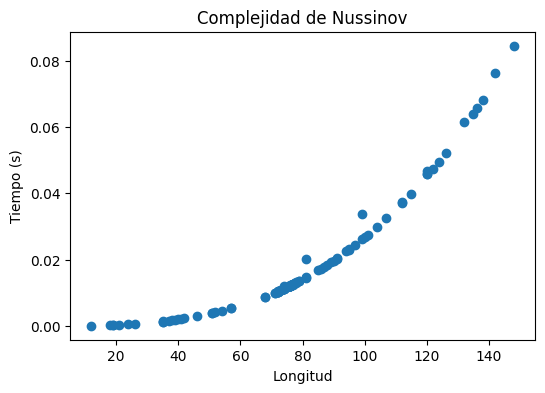

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df["Longitud"], df["Tiempo"])
plt.xlabel("Longitud")
plt.ylabel("Tiempo (s)")
plt.title("Complejidad de Nussinov")
plt.show()

## Relación entre error y longitud

Esta gráfica permite estudiar si la diferencia entre Nussinov y las estructuras reales aumenta con el tamaño de la secuencia.

Si el error tiende a crecer con la longitud, esto reforzaría la idea de que el modelo de Nussinov, al no incorporar restricciones energéticas ni información estructural adicional, resulta cada vez menos realista a medida que aumenta la complejidad de la molécula.

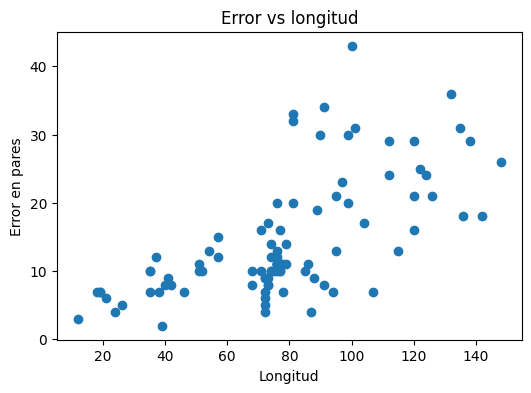

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(df["Longitud"], df["Error_Pares"])
plt.xlabel("Longitud")
plt.ylabel("Error en pares")
plt.title("Error vs longitud")
plt.show()

## Comparación entre emparejamientos predichos y reales

Aquí se comparan directamente los pares predichos por Nussinov con los pares presentes en el dataset real.

Si la mayoría de puntos aparecen por encima de la diagonal ideal, significaría que Nussinov tiende a sobreestimar el número de emparejamientos.

Este resultado sería coherente con la naturaleza del algoritmo, que maximiza pares sin considerar la estabilidad energética de la estructura.

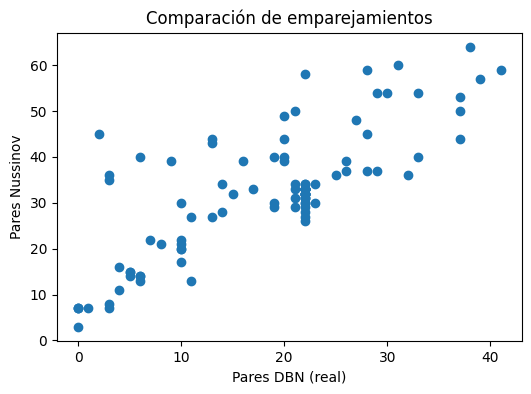

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(df["Pares_DBN"], df["Pares_Nussinov"])
plt.xlabel("Pares DBN (real)")
plt.ylabel("Pares Nussinov")
plt.title("Comparación de emparejamientos")
plt.show()

## Interpretación global de resultados

Los resultados permiten distinguir claramente dos niveles de evaluación:

1. **Corrección algorítmica**: la coincidencia con la solución exacta alternativa en secuencias cortas confirma que la implementación de Nussinov es correcta.
2. **Validez biológica**: la comparación con bpRNA muestra que, aunque el algoritmo es correcto desde el punto de vista combinatorio, no reproduce fielmente las estructuras reales en muchos casos ya que estas tienen en cuenta la energia entr eotras cosas.

En conjunto, esto confirma que Nussinov es un buen modelo didáctico para estudiar programación dinámica y predicción estructural, pero presenta limitaciones importantes como modelo biológico realista.